In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset_dict = {
   'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 
               'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain',
               'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast',
               'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
   'Temp.': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0,
             72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0,
             88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
   'Humid.': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0,
              90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0,
              65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
   'Wind': [False, True, False, False, False, True, True, False, False, False, True,
            True, False, True, True, False, False, True, False, True, True, False,
            True, False, False, True, False, False],
   'Num_Players': [52, 39, 43, 37, 28, 19, 43, 47, 56, 33, 49, 23, 42, 13, 33, 29,
                   25, 51, 41, 14, 34, 29, 49, 36, 57, 21, 23, 41]
}

df = pd.DataFrame(dataset_dict)

df.info()
print(f'\n' * 1)
print(df['Outlook'].value_counts().index)

df = pd.get_dummies(df, prefix="", prefix_sep="", dtype='int')
col_names = ['overcast', 'rain', 'sunny', 'Temp.', 'Humid.', 'Wind', 'Num_Players']
df = df[col_names]
df['Wind'] = df['Wind'].astype(int)

X, y = df.drop(labels='Num_Players', axis=1), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Outlook      28 non-null     object 
 1   Temp.        28 non-null     float64
 2   Humid.       28 non-null     float64
 3   Wind         28 non-null     bool   
 4   Num_Players  28 non-null     int64  
dtypes: bool(1), float64(2), int64(1), object(1)
memory usage: 1.0+ KB


Index(['sunny', 'overcast', 'rain'], dtype='object', name='Outlook')


In [54]:
df_train = pd.concat([X_train, y_train], axis=1)
df_train

,overcast,rain,sunny,Temp.,Humid.,Wind,Num_Players
0,0,0,1,85.0,85.0,0,52
1,0,0,1,80.0,90.0,1,39
2,1,0,0,83.0,78.0,0,43
3,0,1,0,70.0,96.0,0,37
4,0,1,0,68.0,80.0,0,28
5,0,1,0,65.0,70.0,1,19
6,1,0,0,64.0,65.0,1,43
7,0,0,1,72.0,95.0,0,47
8,0,0,1,69.0,70.0,0,56
9,0,1,0,75.0,80.0,0,33


In [55]:
y0 = y_train.mean()
print(f'y_mean: {y0: .2f}')

r1 = y_train - y0
r1.round(2)

y_mean:  37.43


0     14.57
1      1.57
2      5.57
3     -0.43
4     -9.43
5    -18.43
6      5.57
7      9.57
8     18.57
9     -4.43
10    11.57
11   -14.43
12     4.57
13   -24.43
Name: Num_Players, dtype: float64

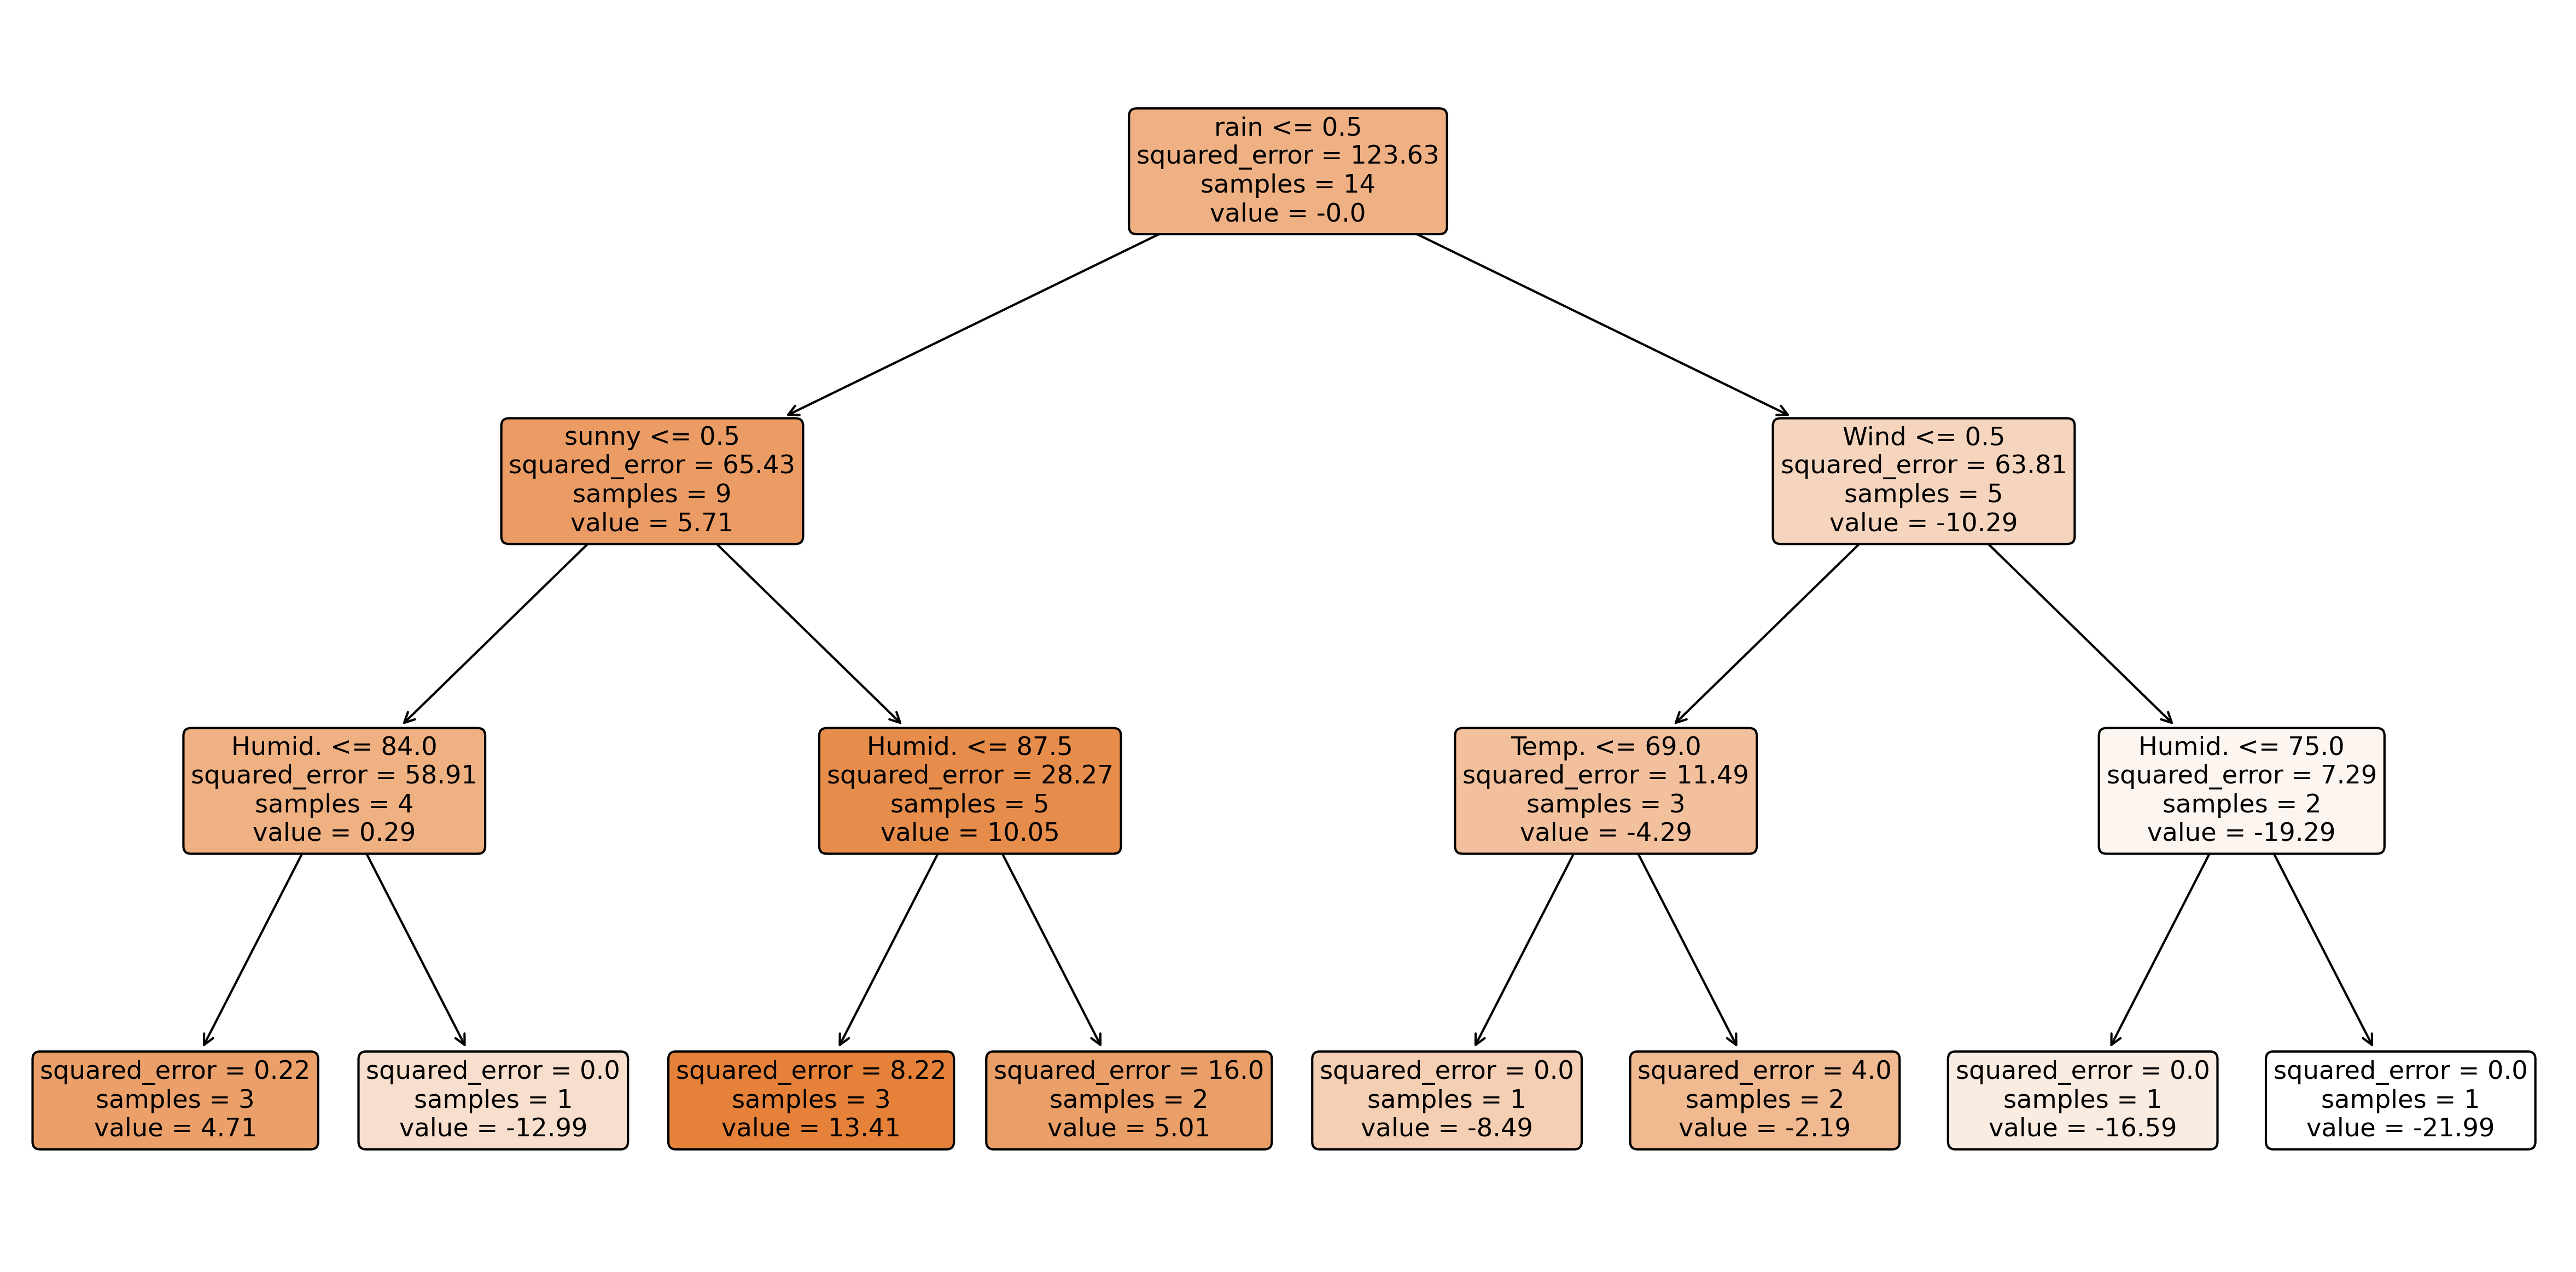

In [62]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

reg = DecisionTreeRegressor(criterion='squared_error', max_depth=3)
reg.fit(X_train, r1)
y1 = reg.predict(X_train)
y0.round(2)

F1 = y0 + 0.1 * y1
F1.round(2)

r2 = y_train - F1
r2

reg = DecisionTreeRegressor(criterion='squared_error', max_depth=3)
reg.fit(X_train, r2)

plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    reg,
    feature_names = X_train.columns,
    filled = True,
    rounded = True,
    precision = 2
)
plt.show()

# pd.DataFrame(y1, columns=['y1']).round(2)

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# Train the model
clf = GradientBoostingRegressor(loss='squared_error', learning_rate=0.1, random_state=42)
clf.fit(X_train, y_train)

# Plot trees 1, 2, 49, and 50
plt.figure(figsize=(11, 20), dpi=300)

for i, tree_idx in enumerate([0, 2, 24, 49]):
    plt.subplot(4, 1, i+1)
    plot_tree(clf.estimators_[tree_idx,0], 
              feature_names=X_train.columns,
              impurity=False,
              filled=True, 
              rounded=True,
              precision=2,
              fontsize=12)
    plt.title(f'Tree {tree_idx + 1}')

plt.suptitle('Decision Trees from GradientBoosting', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<a list of 38 text.Text objects>

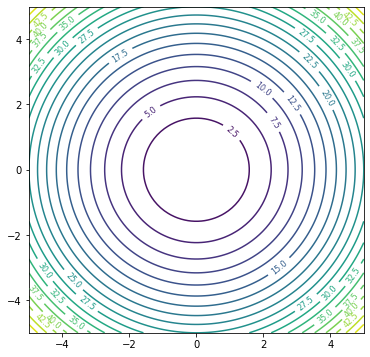

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

def gradient(n_iter, learn_rate, x0):
    points = [x0]
    values = [f(*x0)]
    
    x = x0
    for i in range(n_iter):
        x = x - learn_rate * grad_f(*x)
        points.append(x)
        values.append(f(*x))
    
    return np.array(points), np.array(values)

n_iter = 20
learning_rate = 0.1
x0 = np.array([5, 5])

points, values = gradient(n_iter, learning_rate, x0)

for p, v in zip(points, values):
    # print(f"{p[0]:.2f}\t {p[1]:.2f}\t {v:.2f}")
    pass

X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(6, 6))
cs = ax.contour(X, Y, Z, cmap='viridis', levels=20)
ax.clabel(cs, inline=True, fontsize=8)

In [25]:
XX.shape, YY.shape

((100, 100), (100, 100))